In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
import h5py
f = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r')

In [3]:
list(f.keys())

['chi1x',
 'chi1y',
 'chi1z',
 'chi2x',
 'chi2y',
 'chi2z',
 'dec',
 'det',
 'iota',
 'mtot',
 'psi',
 'q',
 'ra',
 'snr',
 'z']

In [4]:
N_slice = 500

mtot = f['mtot'][::N_slice]
iota = f['iota'][::N_slice]
z = f['z'][::N_slice]

det = f['det'][::N_slice]

X = np.array([mtot, z]).T
y = det

In [5]:
n_featrures = 13
X=[]
for l in ['mtot', 'z', 'dec', 'iota', 'psi', 'q', 'ra', 'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z']:
    X.append(f[l][::N_slice])
X = np.array(X).T
y = np.array(f['det'][::N_slice])

In [6]:
from astroML.utils import split_samples
from astroML.utils import completeness_contamination


(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)

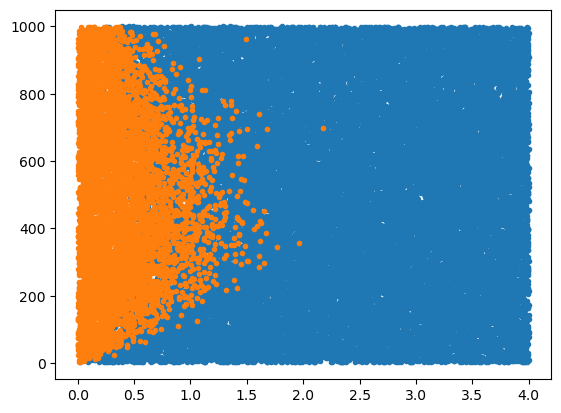

In [7]:
plt.scatter(X[:,1][y==0],X[:,0][y==0],marker='.')
plt.scatter(X[:,1][y==1],X[:,0][y==1],marker='.')


In [8]:
from sklearn.tree import DecisionTreeClassifier


dtree = DecisionTreeClassifier(max_depth=10)
dtree.fit(X_train,y_train)

y_pred = dtree.predict(X_test)
print(dtree.get_depth())
print(dtree.get_n_leaves())

10
340


DecisionTreeClassifier
-

In [9]:
Ncolors = np.arange(1, X.shape[1] + 1)

classifiers = []
predictions = []
Ncolors = np.arange(1, X.shape[1] + 1)
depths = [7, 12]

for depth in depths:
    classifiers.append([])
    predictions.append([])
    for nc in Ncolors:
        clf = DecisionTreeClassifier(random_state=0, max_depth=depth,
                                     criterion='entropy')
        clf.fit(X_train[:, :nc], y_train)
        y_pred = clf.predict(X_test[:, :nc])

        classifiers[-1].append(clf)
        predictions[-1].append(y_pred)

completeness, contamination = completeness_contamination(predictions, y_test)
print("features", Ncolors)
print("completeness", completeness)
print("contamination", contamination)

features [ 1  2  3  4  5  6  7  8  9 10 11 12 13]
completeness [[6.60938533e-04 7.43555849e-01 7.43555849e-01 8.21546596e-01
  8.20224719e-01 7.88499670e-01 7.88499670e-01 7.87838731e-01
  7.88499670e-01 7.85194977e-01 7.85194977e-01 7.85194977e-01
  7.85194977e-01]
 [3.96563120e-03 7.40912095e-01 7.56774620e-01 7.87177792e-01
  7.85855915e-01 8.10310641e-01 8.03701256e-01 8.01718440e-01
  8.01718440e-01 8.16259088e-01 8.24851289e-01 8.18902842e-01
  8.20885658e-01]]
contamination [[0.91666667 0.14122137 0.14383562 0.17899604 0.1792328  0.13488035
  0.13550725 0.13623188 0.13362382 0.13411079 0.13537118 0.13474144
  0.13537118]
 [0.89830508 0.17694567 0.19138418 0.17118998 0.17085077 0.14742698
  0.15905947 0.15411437 0.14936886 0.14236111 0.15332429 0.15656909
  0.15567641]]


In [10]:
print(clf.get_depth())
print(clf.get_n_leaves());

12
452


DecisionTreeClassifier(criterion='entropy', max_depth=12, random_state=0)


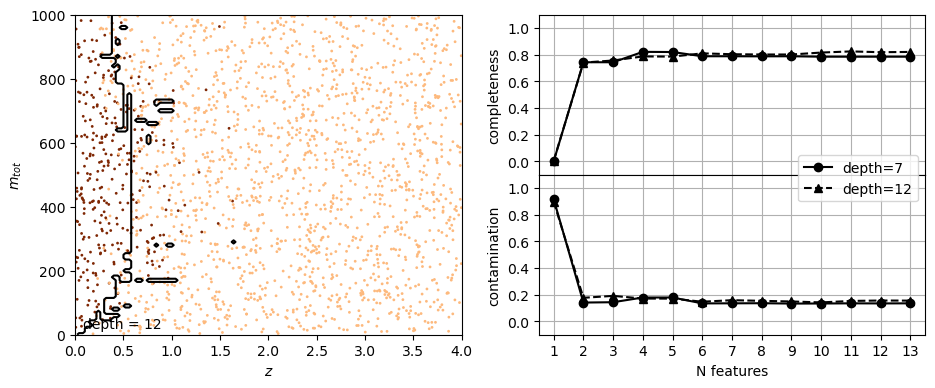

In [11]:
N_plot = 2000

#------------------------------------------------------------
# compute the decision boundary

clf = classifiers[1][1]
print(clf)
xlim = (0., 4.)
ylim = (0., 1e3)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 101),
                     np.linspace(ylim[0], ylim[1], 101))

Z = clf.predict(np.c_[yy.ravel(), xx.ravel()])
Z = Z.reshape(xx.shape)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10, 4))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

ax.contour(xx, yy, Z, [0.5], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$z$')
ax.set_ylabel('$m_{tot}$')

ax.text(0.02, 0.02, "depth = %i" % depths[1],
        transform=ax.transAxes)

# plot completeness vs Ncolors
ax = fig.add_subplot(222)
ax.plot(Ncolors, completeness[0], 'o-k', ms=6, label="depth=%i" % depths[0])
ax.plot(Ncolors, completeness[1], '^--k', ms=6, label="depth=%i" % depths[1])

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, n_featrures+0.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

# plot contamination vs Ncolors
ax = fig.add_subplot(224)
ax.plot(Ncolors, contamination[0], 'o-k', ms=6, label="depth=%i" % depths[0])
ax.plot(Ncolors, contamination[1], '^--k', ms=6, label="depth=%i" % depths[1])
ax.legend(loc='lower right',
          bbox_to_anchor=(1.0, 0.79))

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))

ax.set_xlabel('N features')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, n_featrures+0.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

plt.show()

Best depth
-

In [12]:
from sklearn.metrics import confusion_matrix

In [13]:
completeness_test = []
contamination_test = []
completeness_train = []
contamination_train = []

md_vals = np.arange(1,20)
for md in (md_vals):
    clf = DecisionTreeClassifier(random_state=1, max_depth=md,criterion='entropy')
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    C = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = C.ravel()
    completeness_test.append(tp/(tp+fn))
    contamination_test.append(fp/(tp+fp))

    y_pred = clf.predict(X_train)
    C = confusion_matrix(y_train, y_pred)
    tn, fp, fn, tp = C.ravel()
    completeness_train.append(tp/(tp+fn))
    contamination_train.append(fp/(tp+fp))

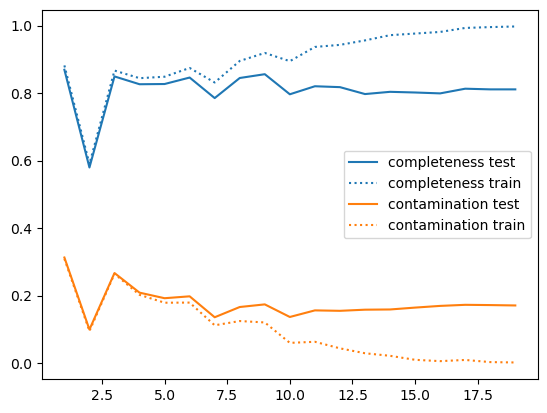

In [14]:
plt.plot(md_vals,completeness_test,label='completeness test',c='C0')
plt.plot(md_vals,completeness_train,label='completeness train',c='C0',ls='dotted')

plt.plot(md_vals,contamination_test,label='contamination test',c='C1')
plt.plot(md_vals,contamination_train,label='contamination train',c='C1',ls='dotted')
plt.legend();

In [15]:
from sklearn.model_selection import GridSearchCV

clf = DecisionTreeClassifier()
drange = np.arange(1,21) 

grid = GridSearchCV(clf, param_grid={'max_depth': drange}, cv=5)
grid.fit(X_train, y_train)

best = grid.best_params_['max_depth']
print("best parameter choice:", best)

best parameter choice: 7


In [16]:
DecisionTreeClassifier(random_state=0, max_depth=best, criterion='entropy')

DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=0)

In [17]:
clf = DecisionTreeClassifier(random_state=0, max_depth=best,
                                     criterion='entropy')
clf.fit(X_train[:, :], y_train)
y_pred = clf.predict(X_test[:, :])

In [18]:
completeness, contamination = completeness_contamination(y_pred, y_test)
print("completeness", completeness)
print("contamination", contamination)

completeness 0.7851949768671513
contamination 0.13537117903930132


In [19]:

y_pred = clf.predict(X_test)
C = confusion_matrix(y_test, y_pred)
print('confusion matrix:\n',C)

tn, fp, fn, tp = C.ravel()
print("\ncompleteness test", tp/(tp+fn))
print("contamination test", fp/(tp+fp))

y_pred_tr = clf.predict(X_train)
C = confusion_matrix(y_train, y_pred_tr)
tn, fp, fn, tp = C.ravel()

print("completeness train", tp/(tp+fn))
print("contamination train", fp/(tp+fp))

print("\nfraction of correct classifications in test", (tp+tn)/(tp+fp+tn+fn))

confusion matrix:
 [[8301  186]
 [ 325 1188]]

completeness test 0.7851949768671513
contamination test 0.13537117903930132
completeness train 0.8313582497721057
contamination train 0.11219274762715989

fraction of correct classifications in test 0.9599666666666666


In [20]:
clf.fit(X_train[:, :2], y_train)
y_pred = clf.predict(X_test[:, :2])

dt = DecisionTreeClassifier(random_state=0, max_depth=best, 
                            criterion='entropy')
dt.fit(X_train, y_train)
yprob = dt.predict_proba(X_test) # If we wanted probabilities rather than the discrete classes

xlim = (0., 4.)
ylim = (0., 1e3)



xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 101),
                     np.linspace(ylim[0], ylim[1], 101))

Z = clf.predict(np.c_[yy.ravel(), xx.ravel()])
Z = Z.reshape(xx.shape)

Text(0.02, 0.02, 'depth = 7')

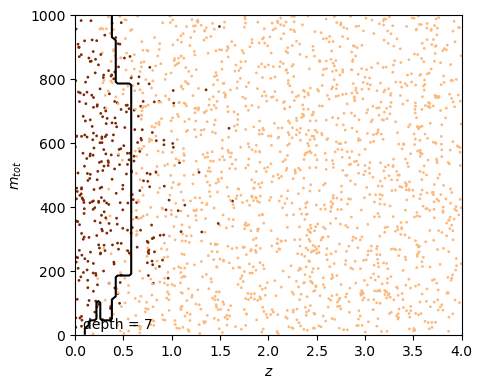

In [21]:
fig = plt.figure(figsize=(10, 4))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

ax.contour(xx, yy, Z, [0.5], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$z$')
ax.set_ylabel('$m_{tot}$')

ax.text(0.02, 0.02, "depth = %i" % best,
        transform=ax.transAxes)


In [22]:
# check on convergence, could be better but to rerun it later i chose not to increase the training size any further

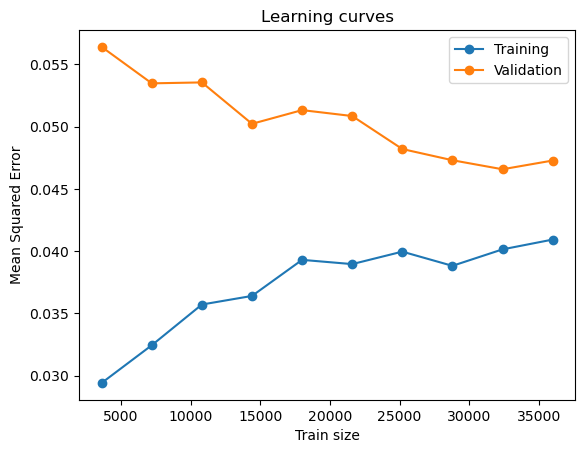

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve


scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

clf = DecisionTreeClassifier(random_state=0, max_depth=best, criterion='entropy')
train_sizes, train_scores_linreg, test_scores_linreg = \
    learning_curve(clf, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)

plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', label="Training")
plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', label="Validation")
                   
plt.xlabel("Train size")
plt.ylabel("Mean Squared Error")
plt.title('Learning curves')
plt.legend(loc="best");

In [24]:
from sklearn.metrics import roc_curve

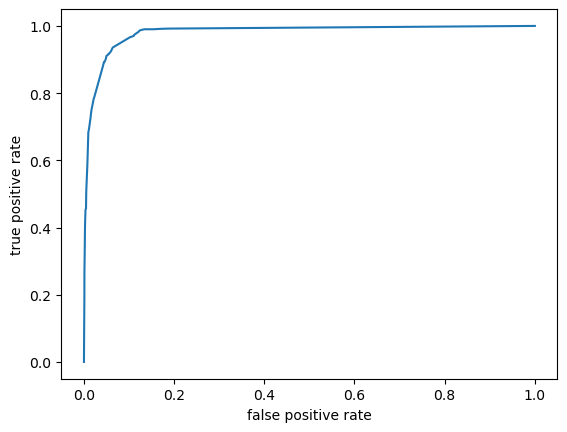

In [25]:
classifiers = []
predictions = []



clf = DecisionTreeClassifier(random_state=0, max_depth=best,criterion='entropy')
clf.fit(X_train[:, :], y_train)
y_pred = clf.predict(X_test[:, :])
y_prob = (clf.predict_proba(X_test[:, :])[:,1])

classifiers.append(clf)
predictions.append(y_pred)

y_prob = clf.predict_proba(X_test[:,:]) [:,1] 

fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
    
plt.xlabel('false positive rate')
plt.ylabel('true positive rate');

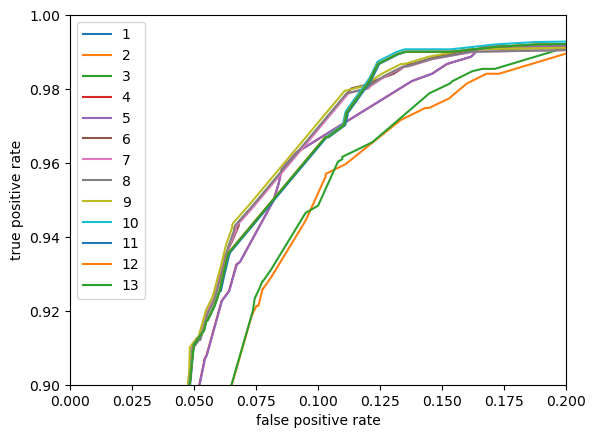

In [26]:
classifiers = []
predictions = []
Ncolors = np.arange(1, X.shape[1] + 1)


for nc in Ncolors:
    clf = DecisionTreeClassifier(random_state=0, max_depth=best,criterion='entropy')
    clf.fit(X_train[:, :nc], y_train)
    y_pred = clf.predict(X_test[:, :nc])

    classifiers.append(clf)
    predictions.append(y_pred)
    
    y_prob = clf.predict_proba(X_test[:,:nc]) [:,1] 
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(nc))
    
plt.legend()
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')

plt.xlim(0,0.2)
plt.ylim(0.9,1);

In [27]:
completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness [6.60938533e-04 7.43555849e-01 7.43555849e-01 8.21546596e-01
 8.20224719e-01 7.88499670e-01 7.88499670e-01 7.87838731e-01
 7.88499670e-01 7.85194977e-01 7.85194977e-01 7.85194977e-01
 7.85194977e-01]
contamination [0.91666667 0.14122137 0.14383562 0.17899604 0.1792328  0.13488035
 0.13550725 0.13623188 0.13362382 0.13411079 0.13537118 0.13474144
 0.13537118]
